# bioacoustic-ssl — a guided tour

One pass through the whole pipeline: Hydra config → dataset → transforms → batch → model.

The example task is **BirdSet HSN**: train on Xeno-Canto recordings of the 21 HSN
species, test on 5 s soundscape windows. Everything here runs on CPU.

In [1]:
import os
from pathlib import Path

os.chdir("..")            # run from the repo root
ROOT = Path.cwd()

from dotenv import load_dotenv

load_dotenv()             # HF token/cache, CA bundle — see .env.example

import matplotlib.pyplot as plt
import torch
from alp_data import dataset_from_config
from hydra import compose, initialize_config_dir
from hydra.utils import instantiate
from omegaconf import OmegaConf
from torch.utils.data import DataLoader

from soundscape_ssl.data import Compose, species_names
from soundscape_ssl.models import MAE

CKPT = ROOT / "checkpoints" / "XC_1M.ckpt"

/home/moritz_earthspecies_org/soundscape_mae/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Config

`configs/train.yaml` is the root for downstream probing (`configs/pretrain.yaml` is the
one for MAE pretraining, used in the last section). Both are composed from
`data/`, `module/` and `trainer/` groups; anything is overridable, on the CLI or here.

In [2]:
with initialize_config_dir(config_dir=str(ROOT / "configs"), version_base=None):
    cfg = compose(config_name="train.yaml", overrides=["data/datasets=train/birdset/hsn"])

print(OmegaConf.to_yaml(cfg.data.datasets.test))

_target_: alp_data.DatasetConfig
dataset_name: birdset
sample_rate: 32000
split: HSN-test_5s
output_take_and_give:
  audio: audio
  label: label
transformations:
- _target_: soundscape_ssl.data.CastConfig
  type: cast
  property: gbifID_multispecies
  extract_all_regex: \d+
  cast_class:
    _target_: polars.List
    inner:
      _target_: polars.Int64
- _target_: soundscape_ssl.data.MultiLabelFromFeatureConfig
  type: mulitlabel_from_feature
  is_multilabel: true
  feature: gbifID_multispecies
  class_ids:
  - 2478259
  - 2481798
  - 2482614
  - 2482803
  - 2484183
  - 2487446
  - 2487825
  - 2490263
  - 2490810
  - 2490935
  - 2491872
  - 2494360
  - 5231132
  - 5231483
  - 7341805
  - 7341834
  - 8169649
  - 8255548
  - 9362842
  - 9510564
  - 9761484



## 2. Datasets

Dataset configs are `alp_data.DatasetConfig` objects: a corpus name, a split, the
columns to keep, and a list of transformations that build the label space.
`dataset_from_config` returns the map-style dataset plus metadata — the metadata
carries the label map, which is where `data.num_classes` comes from.

In [3]:
train_ds, train_meta = dataset_from_config(instantiate(cfg.data.datasets["train"]))
test_ds, test_meta = dataset_from_config(instantiate(cfg.data.datasets["test"]))

label_map = test_meta["mulitlabel_from_feature"]["label_map"]   # {gbifID: index}
class_ids = [cid for cid, _ in sorted(label_map.items(), key=lambda kv: kv[1])]
cfg.data.num_classes = len(class_ids)                           # resolves ${data.num_classes}

print(f"train {len(train_ds):>6} XC recordings")
print(f"test  {len(test_ds):>6} soundscape windows, {cfg.data.num_classes} classes")
print({k: type(v).__name__ for k, v in test_ds[0].items()})

train   7193 XC recordings
test   12000 soundscape windows, 21 classes
{'audio': 'ndarray', 'label': 'list'}


Class ids are gbifIDs. `metadata/gbif_names.parquet` translates them, for every
label space in the repo — it is what ships beside the released head's weights.

In [4]:
names = species_names(class_ids)          # gbifID -> (scientific, common)


def label(class_id: int) -> str:
    scientific, common = names[class_id]
    return f"{common} ({scientific})" if common else scientific


for class_id in class_ids[:5]:
    print(f"{class_id:>8}  {label(class_id)}")

 2478259  Northern Flicker (Colaptes auratus)
 2481798  Spotted Sandpiper (Actitis macularius)
 2482614  Clark's Nutcracker (Nucifraga columbiana)
 2482803  American Dusky Flycatcher (Empidonax oberholseri)
 2484183  Brewer's Blackbird (Euphagus cyanocephalus)


## 3. Transforms

`configs/data/transforms/default.yaml` is a single flat list; each entry carries a
`_stage_` tag saying which stages it applies to. `torch.utils.data.default_collate`
sits in the middle of the list — everything before it is per-sample, everything
after it runs on the batch (spectrogram, SpecAugment, padding).

In [5]:
def build_stage(cfg_list, stage: str) -> list:
    """Instantiate the transforms tagged for `stage` ("train", "val" or "test")."""
    transforms = []
    for item in cfg_list:
        item = OmegaConf.to_container(item, resolve=True)
        if stage in item.pop("_stage_", ["train", "val", "test"]):
            transforms.append(instantiate(item))
    return transforms


for stage in ("train", "test"):
    print(stage, [type(t).__name__ for t in build_stage(cfg.data.transforms, stage)])

train ['TimeShift', 'ToTensor', 'PeakNormalize', 'MultiHotEncoder', 'MeanMix', 'RollingWindow', 'TorchAudiomentationsTransform', 'WavePadding', 'partial', 'BatchSpectrogram', 'TorchAudioTransform', 'BatchPadding']
test ['ToTensor', 'PeakNormalize', 'MultiHotEncoder', 'WavePadding', 'partial', 'BatchSpectrogram', 'BatchPadding']


## 4. A batch

The transform list *is* the collate function. Production runs use
`multiprocessing_context=spawn` and 25 workers (`configs/data/loaders/`); a notebook
is happier with none.

In [6]:
train_loader = DataLoader(
    train_ds, batch_size=4, shuffle=True, num_workers=0,
    collate_fn=Compose(build_stage(cfg.data.transforms, "train")),
)
test_loader = DataLoader(
    test_ds, batch_size=4, shuffle=False, num_workers=0,
    collate_fn=Compose(build_stage(cfg.data.transforms, "test")),
)

train_batch = next(iter(train_loader))
test_batch = next(iter(test_loader))

print({k: tuple(v.shape) for k, v in test_batch.items()})
print("positives per window:", test_batch["label"].sum(1).tolist())

{'label': (4, 21), 'spectrogram': (4, 1, 128, 512)}
positives per window: [1.0, 1.0, 0.0, 0.0]


## 5. Look at an example

128 mel bins × 512 frames = 5 s @ 32 kHz, a 8×32 patch grid at patch size 16.
The train view is augmented (mixed with other recordings, gain, SpecAugment stripes);
the test view is not.

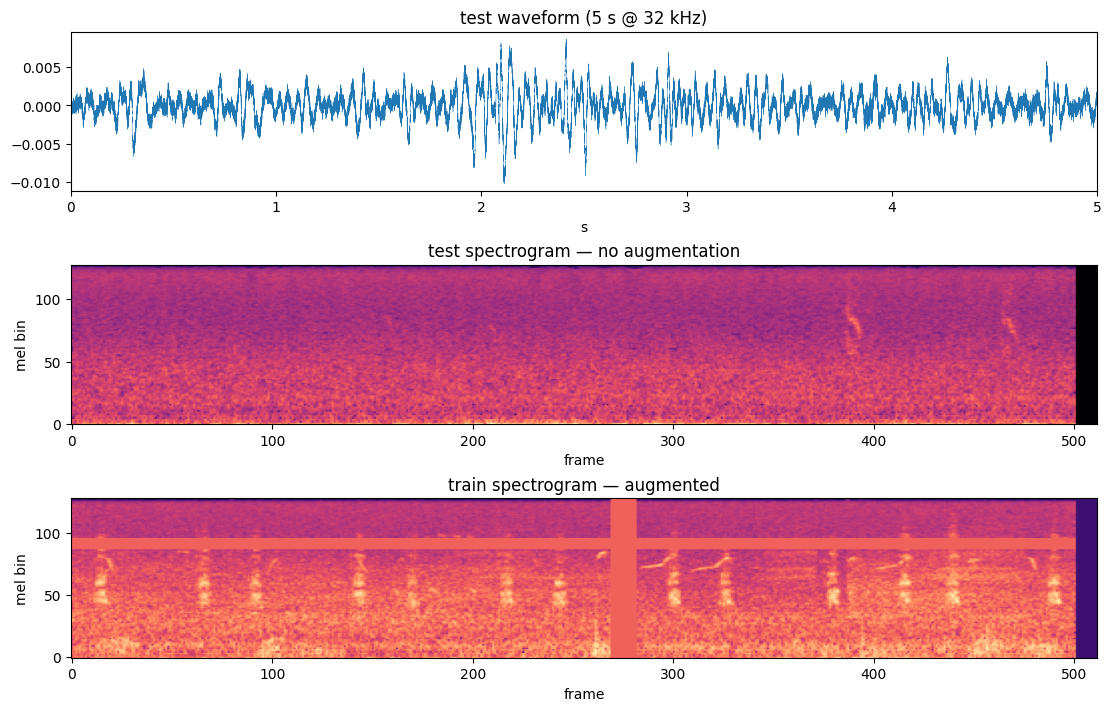

In [7]:
waveform = test_ds[0]["audio"]
fig, axes = plt.subplots(3, 1, figsize=(11, 7), constrained_layout=True)

axes[0].plot(torch.arange(len(waveform)) / 32_000, waveform, lw=0.3)
axes[0].set(title="test waveform (5 s @ 32 kHz)", xlabel="s", xlim=(0, 5))

for ax, spec, title in zip(
    axes[1:],
    [test_batch["spectrogram"][0, 0], train_batch["spectrogram"][0, 0]],
    ["test spectrogram — no augmentation", "train spectrogram — augmented"],
):
    ax.imshow(spec, origin="lower", aspect="auto", cmap="magma")
    ax.set(title=title, ylabel="mel bin", xlabel="frame")

## 6. Model

`module/model=proto/vit` is our ViT-B/16 encoder plus a cosine-prototype head. The
pretrained checkpoint holds an MAE, so only its `encoder.*` weights are read — the
head stays at its fresh init, and `freeze_backbone()` makes this a probe.

In [8]:
model = instantiate(cfg.module.model)

state_dict = torch.load(CKPT, map_location="cpu", weights_only=False)["model"]
encoder_sd = {k.removeprefix("encoder."): v for k, v in state_dict.items() if k.startswith("encoder.")}
print(model.load_state_dict(encoder_sd, strict=False))   # missing head.* is expected

model.freeze_backbone()
model.eval()

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"{type(model).__name__}: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M params, "
      f"{trainable / 1e6:.1f}M trainable")

_IncompatibleKeys(missing_keys=['head.prototype_vectors', 'head.linear.weight', 'head.linear.bias'], unexpected_keys=[])
ViTProtoFloat: 85.6M params, 0.3M trainable


### Forward pass

The head is untrained here, so the logits are noise — a real probe trains it for 1250
steps (`scripts/birdset_eval.py`). What this shows is the shape of the contract:
`(B, 1, 128, 512)` spectrogram in, `(B, num_classes)` multi-label logits out.

In [9]:
with torch.no_grad():
    logits = model(test_batch["spectrogram"])

probs = logits.sigmoid()
print("logits:", tuple(logits.shape))

for i in range(len(probs)):
    top = probs[i].topk(3)
    true = [class_ids[j] for j in test_batch["label"][i].nonzero().flatten().tolist()]
    print(f"window {i}: true {[label(c) for c in true]}")
    for score, j in zip(top.values.tolist(), top.indices.tolist()):
        print(f"    {score:.3f}  {label(class_ids[j])}")

logits: (4, 21)
window 0: true ['Grey-crowned Rosy Finch (Leucosticte tephrocotis)']
    0.527  Mangrove Warbler (Setophaga petechia)
    0.510  Grey-crowned Rosy Finch (Leucosticte tephrocotis)
    0.509  White-crowned Sparrow (Zonotrichia leucophrys)
window 1: true ['Grey-crowned Rosy Finch (Leucosticte tephrocotis)']
    0.526  Mangrove Warbler (Setophaga petechia)
    0.511  Grey-crowned Rosy Finch (Leucosticte tephrocotis)
    0.506  Orange-crowned Warbler (Leiothlypis celata)
window 2: true []
    0.526  Mangrove Warbler (Setophaga petechia)
    0.510  Grey-crowned Rosy Finch (Leucosticte tephrocotis)
    0.509  White-crowned Sparrow (Zonotrichia leucophrys)
window 3: true []
    0.521  Mangrove Warbler (Setophaga petechia)
    0.512  Grey-crowned Rosy Finch (Leucosticte tephrocotis)
    0.506  White-crowned Sparrow (Zonotrichia leucophrys)


## 7. The MAE itself

The same checkpoint, loaded whole this time. `MAE.forward` masks 75 % of the patches,
encodes the rest, and reconstructs the missing ones. Loss is computed on masked patches
only, in per-patch normalised space (`norm_pix_loss`), so undo that scaling to look at
the reconstruction.

In [10]:
with initialize_config_dir(config_dir=str(ROOT / "configs"), version_base=None):
    pretrain_cfg = compose(config_name="pretrain.yaml")

mae = MAE(**pretrain_cfg.module.model)
print(mae.load_state_dict(state_dict))
mae.eval()

torch.manual_seed(0)
with torch.no_grad():
    out = mae(test_batch["spectrogram"])

print({k: (round(v.item(), 4) if v.ndim == 0 else tuple(v.shape)) for k, v in out.items()})

<All keys matched successfully>


{'loss': 0.7038, 'pred': (4, 256, 256), 'mask': (4, 256), 'latent': (4, 64, 768), 'cls_token': (4, 768)}


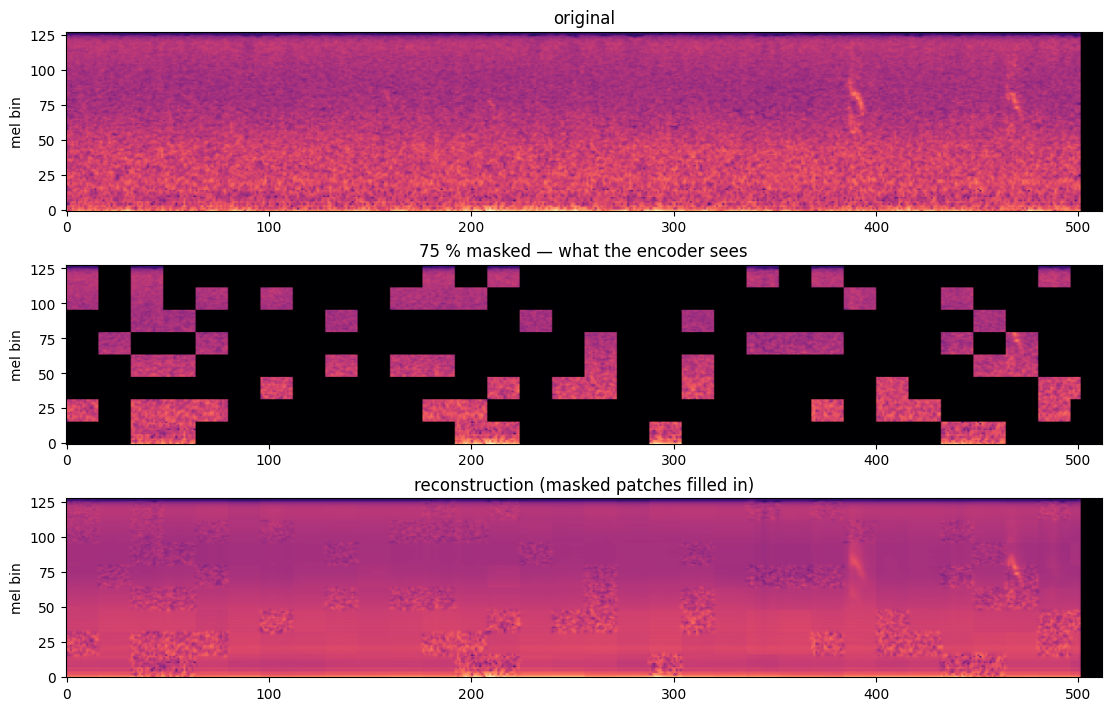

In [11]:
def unpatchify(patches: torch.Tensor) -> torch.Tensor:
    """(B, N, p*p) patch tokens -> (B, 1, 128, 512) spectrogram."""
    (h, w), p = mae.encoder.patch_embed.grid_size, mae.patch_size
    x = patches.reshape(-1, h, w, p, p, 1)
    x = torch.einsum("nhwpqc->nchpwq", x)
    return x.reshape(-1, 1, h * p, w * p)


target = mae.patchify(test_batch["spectrogram"])
mean, var = target.mean(-1, keepdim=True), target.var(-1, keepdim=True)
pred = out["pred"] * (var + 1e-4) ** 0.5 + mean          # undo norm_pix_loss
mask = out["mask"].unsqueeze(-1)                          # 1 = masked out

visible = unpatchify(target * (1 - mask) + mask * target.min())
filled = unpatchify(target * (1 - mask) + pred * mask)

fig, axes = plt.subplots(3, 1, figsize=(11, 7), constrained_layout=True)
for ax, spec, title in zip(
    axes,
    [test_batch["spectrogram"][0, 0], visible[0, 0], filled[0, 0]],
    ["original", "75 % masked — what the encoder sees", "reconstruction (masked patches filled in)"],
):
    ax.imshow(spec, origin="lower", aspect="auto", cmap="magma", vmin=0, vmax=2)
    ax.set(title=title, ylabel="mel bin")